In [2]:
import pandas as pd
import json

In [10]:
# read json
with open('/tank-1/data/NLST/json/test_oct2.json', 'r') as f:
    test_monai = json.load(f)

In [11]:
df = pd.DataFrame(test_monai)
df.head()

,image,mask,y,time_at_event,y_seq,y_mask,series,study,screen_timepoint,pid,institution,cancer_laterality,sex,smoking_status,pleural_effusion,nodule_greater_4mm,emphysema,fibrosis,age,annotation
0,/tank-1/data/NLST/npy/images/118675/1.2.840.11...,/tank-1/data/NLST/npy/masks/118675/1.2.840.113...,0,5,"[0, 0, 0, 0, 0, 0]","[1, 1, 1, 1, 1, 1]",1.2.840.113654.2.55.13900382241625227628604789...,1.2.840.113654.2.55.17593563095251920105404224...,1,118675,BG,"[4, False]",1,1,0,0,0,0,56,NaN
1,/tank-1/data/NLST/npy/images/118675/1.2.840.11...,/tank-1/data/NLST/npy/masks/118675/1.2.840.113...,0,5,"[0, 0, 0, 0, 0, 0]","[1, 1, 1, 1, 1, 1]",1.2.840.113654.2.55.33222427723063579459149305...,1.2.840.113654.2.55.12223505568481621987156735...,0,118675,BG,"[4, False]",1,1,0,1,0,0,56,NaN
2,/tank-1/data/NLST/npy/images/118675/1.2.840.11...,/tank-1/data/NLST/npy/masks/118675/1.2.840.113...,0,4,"[0, 0, 0, 0, 0, 0]","[1, 1, 1, 1, 1, 0]",1.2.840.113654.2.55.75231956342037237079901478...,1.2.840.113654.2.55.87592473324798667900007803...,2,118675,BG,"[4, False]",1,1,0,0,0,0,56,NaN
3,/tank-1/data/NLST/npy/images/112525/1.2.840.11...,/tank-1/data/NLST/npy/masks/112525/1.2.840.113...,0,5,"[0, 0, 0, 0, 0, 0]","[1, 1, 1, 1, 1, 1]",1.2.840.113654.2.55.24746190892063795462564488...,1.2.840.113654.2.55.13374638388892969258446202...,0,112525,AA,"[4, False]",1,0,0,0,0,0,65,NaN
4,/tank-1/data/NLST/npy/images/112525/1.2.840.11...,/tank-1/data/NLST/npy/masks/112525/1.2.840.113...,0,5,"[0, 0, 0, 0, 0, 0]","[1, 1, 1, 1, 1, 1]",1.2.840.113654.2.55.15048453837590866034758706...,1.2.840.113654.2.55.10596412614573153349115691...,1,112525,AA,"[4, False]",1,0,0,0,0,0,65,NaN


In [4]:
only_cancer = df['y'] == 1

In [5]:
df_cancer = df[only_cancer]

In [6]:
# Get all where 'annotation' in not NaN
df_cancer_with_annotation = df_cancer[~df_cancer['annotation'].isna()]

In [7]:
# Convert it to a list of dictionaries
cancer_with_annotation = df_cancer_with_annotation.to_dict(orient='records')

In [9]:
len(cancer_with_annotation)

95

In [10]:
# Save this to a json file
with open('/tank-1/data/NLST/json/test_only_annotation.json', 'w') as f:
    json.dump(cancer_with_annotation, f, indent=4)

# FML

In [ ]:
with open('/tank-1/data/NLST/json/train_sybil_code.json', 'r') as f:
    train_monai = json.load(f)
with open('/tank-1/data/NLST/json/dev_sybil_code.json', 'r') as f:
    val_monai = json.load(f)
with open('/tank-1/data/NLS T/json/test_oct2.json', 'r') as f:
    test_monai = json.load(f)

In [7]:
hospitalA = train_monai[140:150]
hospitalB = train_monai[150:160]

In [8]:
# Save this to a json file
with open('/tank-1/data/NLST/json/hospitalA.json', 'w') as f:
    json.dump(hospitalA, f, indent=4)

with open('/tank-1/data/NLST/json/hospitalB.json', 'w') as f:
    json.dump(hospitalB, f, indent=4)

In [2]:
import pickle

In [3]:
# Read pickle file
with open('/tank-1/users/chev/lung/lung_cancer_risk_trainval.pickle', 'rb') as f:
    trainval = pickle.load(f)

In [4]:
# Read pickle file
with open('/tank-1/users/chev/lung/lung_cancer_risk_test.pickle', 'rb') as f:
    test = pickle.load(f)

In [5]:
test.keys()

dict_keys(['keys', 'pids', 'lung_bboxes', 'labels', 'pixel_size', 'data_path', 'npy_path', 'clinical_data', 'questions', 'data_name'])

In [6]:
len(set(test['pids'])), len(set(test['keys']))

(2279, 10308)

In [7]:
len(set(trainval['pids'])), len(set(trainval['keys']))

(10183, 46221)

In [35]:
test_niu = set(test['pids'])
test_our = set(df['pid'])

# FInd A - B, B - A, and A ∩ B
len(test_our - test_niu), len(test_niu - test_our), len(test_our.intersection(test_niu))

(45, 129, 2150)

In [36]:
series_our = set(df['series'])
series_niu = set(test['keys'])
# Find A - B, B - A, and A ∩ B
len(series_our - series_niu), len(series_niu - series_our), len(series_our.intersection(series_niu))

(287, 4166, 6142)

In [37]:
test_niu

{'132669',
 '103446',
 '113097',
 '209029',
 '112971',
 '205247',
 '112790',
 '108207',
 '218482',
 '129955',
 '112953',
 '123949',
 '128836',
 '104171',
 '115873',
 '134418',
 '127536',
 '109030',
 '112119',
 '123577',
 '207903',
 '128255',
 '131456',
 '204747',
 '207474',
 '112856',
 '115144',
 '201794',
 '205781',
 '215887',
 '105030',
 '100343',
 '119391',
 '126909',
 '113357',
 '102549',
 '200929',
 '107246',
 '125515',
 '210232',
 '217991',
 '128347',
 '100611',
 '218127',
 '218739',
 '200128',
 '215784',
 '126412',
 '130840',
 '200538',
 '103095',
 '108149',
 '113446',
 '101943',
 '108166',
 '108461',
 '125661',
 '123670',
 '127907',
 '210733',
 '119118',
 '204029',
 '211013',
 '120266',
 '124455',
 '100184',
 '128857',
 '112296',
 '111063',
 '112889',
 '127021',
 '107888',
 '214592',
 '130679',
 '108761',
 '209120',
 '213485',
 '103878',
 '200988',
 '210993',
 '124971',
 '207544',
 '105995',
 '106280',
 '119358',
 '101457',
 '112270',
 '118019',
 '127000',
 '116587',
 '108054',

In [50]:
"1.2.840.113654.2.55.151596107767186262127486566684973326628" in (test['keys'])

True

In [44]:
test['keys']

['1.2.840.113654.2.55.330656333774433317291205463243337143455',
 '1.2.840.113654.2.55.148981425884825940179466259981962976653',
 '1.2.840.113654.2.55.17324290215190661437113320769488297837',
 '1.2.840.113654.2.55.212474527960092593758511400493563127113',
 '1.2.840.113654.2.55.334485802662414832013516392011907420850',
 '1.2.840.113654.2.55.240231128564881525363489796879328810792',
 '1.2.840.113654.2.55.335938848402215862539398120263494500079',
 '1.2.840.113654.2.55.50761756412482430061802871163319122196',
 '1.2.840.113654.2.55.135088253786049275791463451273034430925',
 '1.2.840.113654.2.55.187528836828455119219418209494288474548',
 '1.2.840.113654.2.55.180847376201814968135928364045219185070',
 '1.2.840.113654.2.55.212073191843752504482268398825318038163',
 '1.2.840.113654.2.55.197513090202695956657984586590393643330',
 '1.2.840.113654.2.55.288171856643960722425287471921156371975',
 '1.2.840.113654.2.55.259460044646143263801665158326374365115',
 '1.2.840.113654.2.55.31385368471999939288

In [2]:
# Load a pickle file
import pickle
with open('/tank-1/users/chev/lung/files/Shetty_et_al(Google)_data_splits.p', 'rb') as f:
    trainval = pickle.load(f)

In [5]:
c = 0
for k, v in trainval.items():
    if v['split'] == 'test':
        # Count the number of pids
        c+= 1

# Peter Mikhael's list

In [41]:
import pandas as pd
import os
from tqdm import tqdm

In [42]:
# Import csv file
filtered_df = pd.read_csv('/tank-1/users/chev/lung/pids_series.csv')
df = pd.read_csv("/tank-1/data/NLST/tab-data/sct_image_series_d040722.csv")
participants_df = pd.read_csv("/tank-1/data/NLST/tab-data/participant_d040722.csv")

/tmp/ipykernel_2936160/2677991246.py:4: DtypeWarning: Columns (239,240,348) have mixed types. Specify dtype option on import or set low_memory=False.
  participants_df = pd.read_csv("/tank-1/data/NLST/tab-data/participant_d040722.csv")


In [43]:
def get_label(pt_metadata, screen_timepoint, max_followup):
    days_since_rand = pt_metadata["scr_days{}".format(screen_timepoint)]
    days_to_cancer_since_rand = pt_metadata["candx_days"]
    days_to_cancer = days_to_cancer_since_rand - days_since_rand
    years_to_cancer = (
        int(days_to_cancer // 365) if days_to_cancer_since_rand > -1 else 100
    )
    days_to_last_followup = int(pt_metadata["fup_days"] - days_since_rand)
    years_to_last_followup = days_to_last_followup // 365
    y = years_to_cancer < max_followup
    y_seq = [0] * max_followup
    cancer_timepoint = pt_metadata["cancyr"]
    if y:
        if years_to_cancer > -1:
            assert screen_timepoint <= cancer_timepoint
        time_at_event = years_to_cancer
        y_seq[years_to_cancer:] = [1] * len(y_seq[years_to_cancer:])
    else:
        time_at_event = min(years_to_last_followup, max_followup - 1)
    y_mask = [1] * (time_at_event + 1) + [0] * (max_followup - (time_at_event + 1))
    return y, y_seq, y_mask, time_at_event


def get_cancer_lobe(pt_metadata):
    """
    Return if cancer in left or right

    right: (rhil, right hilum), (rlow, right lower lobe), (rmid, right middle lobe), (rmsb, right main stem), (rup, right upper lobe),
    left: (lhil, left hilum),  (llow, left lower lobe), (lmsb, left main stem), (lup, left upper lobe), (lin, lingula)
    else: (med, mediastinum), (oth, other), (unk, unknown), (car, carina)
    """
    right_keys = ["locrlow", "locrmid", "locrup"]
    hull_keys = ["locrhil", "locrmsb", 'loclmsb', "loclhil", "loccar"]
    left_keys = ["loclup", "locllow", "loclin"]
    whole_lung_keys = ["locmed", "locoth", "locunk"]

    cancer_lobe_dict = {
        'locrlow':(1, 6),
        'locrmid': (1, 5),
        'locrup': (1, 4),
        'loclup': (2, 2),
        'locllow': (2, 3),
        'loclin': (2, 2),
        'locrhil': (3, False),
        'locrmsb': (3, False),
        'loclmsb': (4, False),
        'loclhil': (4, False),
        'loccar': (5, False),
        'locmed': (5, False),
        'locoth': (5, False),
        'locunk': (5, False),
    }

    for key, values in cancer_lobe_dict.items():
        if pt_metadata[key] > 0:
            return values
        else:
            return (4, False)

In [44]:
# Add tqdm for progress bar

data_root = '/tank-1/data/NLST/npy/'
max_followup = 6
dataset = []
Series = []
no_image = 0
no_mask = 0
no_label = 0
for index, row in tqdm(filtered_df.iterrows(), total=filtered_df.shape[0]):
    pid = int(row['PID'])
    _series = str(row['Series'])
    pt_metadata = participants_df[participants_df.pid == int(pid)].to_dict(orient="records")[0]
    series_df = df[df['seriesinstanceuid'] == str(row['Series'])]
    study = series_df['studyuid'].iloc[0]
    screen_timepoint = series_df['study_yr'].iloc[0]
    img = os.path.join(data_root, "images", str(pid), str(study), str(_series), f"{_series}.npy")
    mask = os.path.join(data_root, "masks", str(pid), str(study), str(_series), f"{_series}.npy")
    annotation = os.path.join(data_root, "annotations", str(pid), str(study), str(_series), f"{_series}.npy")
    if not os.path.isfile(img):
        no_image += 1
        print(f"Image not found: {img}")
        Series.append(_series)
        continue
    if not os.path.isfile(mask):
        no_mask += 1
        print(f"Mask not found: {mask}")
        # Series.append(_series)
        mask = None
        # continue
    if not os.path.exists(annotation):
        annotation = None

    try:
        y, y_seq, y_mask, time_at_event = get_label(pt_metadata, screen_timepoint, max_followup)
    except ValueError:
        no_label += 1
        print(f"Label error for PID: {pid}, Series: {_series}")
        Series.append(_series)
        pass

    if annotation is None:
        sample = {
            "image": img,
            # "mask": mask,
            "y": int(y),
            "time_at_event": time_at_event,
            "y_seq": y_seq,
            "y_mask": y_mask,
            "series": str(_series),
            "study": str(study),
            "screen_timepoint": int(screen_timepoint),
            "pid": str(pid),
            "institution": pt_metadata["cen"][0],
            "cancer_laterality": get_cancer_lobe(pt_metadata),
            # "cancer_laterality": get_cancer_side(pt_metadata),
        }
    else:
        sample = {
            "image": img,
            # "mask": mask,
            "annotation": annotation,
            "y": int(y),
            "time_at_event": time_at_event,
            "y_seq": y_seq,
            "y_mask": y_mask,
            "series": str(_series),
            "study": str(study),
            "screen_timepoint": int(screen_timepoint),
            "pid": str(pid),
            "institution": pt_metadata["cen"][0],
            "cancer_laterality": get_cancer_lobe(pt_metadata),
            # "cancer_laterality": get_cancer_side(pt_metadata),
        }
    dataset.append(sample)

    # break

  3%|▎         | 192/6286 [00:03<01:51, 54.61it/s]

Mask not found: /tank-1/data/NLST/npy/masks/216329/1.3.6.1.4.1.14519.5.2.1.7009.9004.726728057306218026057157324481/1.3.6.1.4.1.14519.5.2.1.7009.9004.101561443396929573921767809956/1.3.6.1.4.1.14519.5.2.1.7009.9004.101561443396929573921767809956.npy
Mask not found: /tank-1/data/NLST/npy/masks/216329/1.3.6.1.4.1.14519.5.2.1.7009.9004.317644179105280024305768026038/1.3.6.1.4.1.14519.5.2.1.7009.9004.411484390325959365975717298786/1.3.6.1.4.1.14519.5.2.1.7009.9004.411484390325959365975717298786.npy


  5%|▌         | 336/6286 [00:06<01:54, 52.19it/s]

Mask not found: /tank-1/data/NLST/npy/masks/215707/1.3.6.1.4.1.14519.5.2.1.7009.9004.338674887325262543503606526507/1.3.6.1.4.1.14519.5.2.1.7009.9004.232170770500710220953842724842/1.3.6.1.4.1.14519.5.2.1.7009.9004.232170770500710220953842724842.npy


  8%|▊         | 480/6286 [00:09<01:50, 52.76it/s]

...

 76%|███████▌  | 4792/6286 [01:37<00:32, 45.80it/s]

Image not found: /tank-1/data/NLST/npy/images/123633/1.2.840.113654.2.55.247467091040554702639211438071387901498/1.2.840.113654.2.55.10179001555336958354941808051600292846/1.2.840.113654.2.55.10179001555336958354941808051600292846.npy


 93%|█████████▎| 5847/6286 [01:58<00:08, 49.99it/s]

Image not found: /tank-1/data/NLST/npy/images/116215/1.2.840.113654.2.55.309580950170634720099498734035528713365/1.2.840.113654.2.55.244293130447967327961087897263616063724/1.2.840.113654.2.55.244293130447967327961087897263616063724.npy


100%|██████████| 6286/6286 [02:07<00:00, 49.29it/s]


In [45]:
d = pd.DataFrame(dataset)

In [46]:
# Save Dataset to a json file
with open("/tank-1/data/NLST/json/test_mikhael.json", "w") as fp:
    json.dump(dataset, fp, indent=4)

In [47]:
len(set(d['pid']))

2202

In [48]:
len(Series)

9

In [35]:
# Save Series to a text file
with open('/tank-1/users/chev/lung/series_not_found.txt', 'w') as f:
    for item in Series:
        f.write("%s\n" % item)

# M3FM dict

In [32]:
# Read pickle using pandas
filtered_df = pd.read_pickle('/tank-1/users/chev/lung/lung_cancer_risk_test.pickle')

In [33]:
data_root = '/tank-1/data/NLST/npy/'
max_followup = 6
dataset = []
Series = []
no_image = 0
no_mask = 0
no_label = 0
for _series in tqdm(filtered_df['keys'], total=len(filtered_df['keys'])):
    series_df = df[df['seriesinstanceuid'] == str(_series)]
    pid = series_df['pid'].iloc[0]
    pt_metadata = participants_df[participants_df.pid == int(pid)].to_dict(orient="records")[0]
    study = series_df['studyuid'].iloc[0]
    screen_timepoint = series_df['study_yr'].iloc[0]
    img = os.path.join(data_root, "images", str(pid), str(study), str(_series), f"{_series}.npy")
    mask = os.path.join(data_root, "masks", str(pid), str(study), str(_series), f"{_series}.npy")
    annotation = os.path.join(data_root, "annotations", str(pid), str(study), str(_series), f"{_series}.npy")
    if not os.path.isfile(img):
        no_image += 1
        print(f"Image not found: {img}")
        Series.append(_series)
        continue
    if not os.path.isfile(mask):
        no_mask += 1
        print(f"Mask not found: {mask}")
        # Series.append(_series)
        mask = None
        # continue
    if not os.path.exists(annotation):
        annotation = None

    try:
        y, y_seq, y_mask, time_at_event = get_label(pt_metadata, screen_timepoint, max_followup)
    except ValueError:
        no_label += 1
        print(f"Label error for PID: {pid}, Series: {_series}")
        Series.append(_series)
        pass

    if annotation is None:
        sample = {
            "image": img,
            # "mask": mask,
            "y": int(y),
            "time_at_event": time_at_event,
            "y_seq": y_seq,
            "y_mask": y_mask,
            "series": str(_series),
            "study": str(study),
            "screen_timepoint": int(screen_timepoint),
            "pid": str(pid),
            "institution": pt_metadata["cen"][0],
            "cancer_laterality": get_cancer_lobe(pt_metadata),
            # "cancer_laterality": get_cancer_side(pt_metadata),
        }
    else:
        sample = {
            "image": img,
            # "mask": mask,
            "annotation": annotation,
            "y": int(y),
            "time_at_event": time_at_event,
            "y_seq": y_seq,
            "y_mask": y_mask,
            "series": str(_series),
            "study": str(study),
            "screen_timepoint": int(screen_timepoint),
            "pid": str(pid),
            "institution": pt_metadata["cen"][0],
            "cancer_laterality": get_cancer_lobe(pt_metadata),
            # "cancer_laterality": get_cancer_side(pt_metadata),
        }
    dataset.append(sample)

    # break

 15%|█▌        | 1569/10308 [00:31<02:54, 49.95it/s]

Mask not found: /tank-1/data/NLST/npy/masks/106551/1.2.840.113654.2.55.98512980251218772244926652192112465100/1.2.840.113654.2.55.139788481664645992300987813108658875865/1.2.840.113654.2.55.139788481664645992300987813108658875865.npy
Mask not found: /tank-1/data/NLST/npy/masks/106551/1.2.840.113654.2.55.98512980251218772244926652192112465100/1.2.840.113654.2.55.26594285841741942626104097054200104886/1.2.840.113654.2.55.26594285841741942626104097054200104886.npy


 16%|█▌        | 1629/10308 [00:32<02:29, 58.15it/s]

Mask not found: /tank-1/data/NLST/npy/masks/106806/1.2.840.113654.2.55.174055188621048956530104677077930120849/1.2.840.113654.2.55.18257049801994484256729365582253176564/1.2.840.113654.2.55.18257049801994484256729365582253176564.npy
Mask not found: /tank-1/data/NLST/npy/masks/106806/1.2.840.113654.2.55.174055188621048956530104677077930120849/1.2.840.113654.2.55.291748168916511905983388659943620669460/1.2.840.113654.2.55.291748168916511905983388659943620669460.npy
Mask not found: /tank-1/data/NLST/npy/masks/106806/1.2.840.113654.2.55.132725932398155557599079579111182815629/1.2.840.113654.2.55.69279791763795313768057187953087727045/1.2.840.113654.2.55.69279791763795313768057187953087727045.npy
Mask not found: /tank-1/data/NLST/npy/masks/106806/1.2.840.113654.2.55.132725932398155557599079579111182815629/1.2.840.113654.2.55.118417023821250690607787528259626554831/1.2.840.113654.2.55.118417023821250690607787528259626554831.npy
Mask not found: /tank-1/data/NLST/npy/masks/106806/1.2.840.11365

 36%|███▌      | 3733/10308 [01:14<02:00, 54.54it/s]

...

100%|█████████▉| 10260/10308 [03:25<00:01, 47.09it/s]

Mask not found: /tank-1/data/NLST/npy/masks/218657/1.3.6.1.4.1.14519.5.2.1.7009.9004.194400183284934387087776622483/1.3.6.1.4.1.14519.5.2.1.7009.9004.333179012530924486577453683461/1.3.6.1.4.1.14519.5.2.1.7009.9004.333179012530924486577453683461.npy
Mask not found: /tank-1/data/NLST/npy/masks/218657/1.3.6.1.4.1.14519.5.2.1.7009.9004.194400183284934387087776622483/1.3.6.1.4.1.14519.5.2.1.7009.9004.179051787202083565573430339374/1.3.6.1.4.1.14519.5.2.1.7009.9004.179051787202083565573430339374.npy
Mask not found: /tank-1/data/NLST/npy/masks/218657/1.3.6.1.4.1.14519.5.2.1.7009.9004.194400183284934387087776622483/1.3.6.1.4.1.14519.5.2.1.7009.9004.522126805728138399955557647163/1.3.6.1.4.1.14519.5.2.1.7009.9004.522126805728138399955557647163.npy
Mask not found: /tank-1/data/NLST/npy/masks/218657/1.3.6.1.4.1.14519.5.2.1.7009.9004.158111922941694905538849611883/1.3.6.1.4.1.14519.5.2.1.7009.9004.206431122393928194298892188617/1.3.6.1.4.1.14519.5.2.1.7009.9004.206431122393928194298892188617.npy


100%|█████████▉| 10302/10308 [03:26<00:00, 51.80it/s]

Mask not found: /tank-1/data/NLST/npy/masks/218803/1.3.6.1.4.1.14519.5.2.1.7009.9004.283309467680259806854830990264/1.3.6.1.4.1.14519.5.2.1.7009.9004.996883099911003562107664506979/1.3.6.1.4.1.14519.5.2.1.7009.9004.996883099911003562107664506979.npy
Mask not found: /tank-1/data/NLST/npy/masks/218803/1.3.6.1.4.1.14519.5.2.1.7009.9004.286955105204160004775775696587/1.3.6.1.4.1.14519.5.2.1.7009.9004.408013121247195770142219139858/1.3.6.1.4.1.14519.5.2.1.7009.9004.408013121247195770142219139858.npy
Mask not found: /tank-1/data/NLST/npy/masks/218803/1.3.6.1.4.1.14519.5.2.1.7009.9004.995372480518514578164934065930/1.3.6.1.4.1.14519.5.2.1.7009.9004.119556229581427750897064261810/1.3.6.1.4.1.14519.5.2.1.7009.9004.119556229581427750897064261810.npy


100%|██████████| 10308/10308 [03:26<00:00, 49.85it/s]


In [34]:
d = pd.DataFrame(dataset)


In [36]:
len(d['series'].unique())

10300

In [37]:
len(set(filtered_df['keys']))

10308

In [40]:
# Save Dataset to a json file
with open("/tank-1/data/NLST/json/test_m3fm.json", "w") as fp:
    json.dump(dataset, fp, indent=4)

# Philips visualization

In [29]:
import torch
import matplotlib.pyplot as plt

In [ ]:
root = "/tank-1/data/checkpoints/viz/201674/1.3.6.1.4.1.14519.5.2.1.7009.9004.273496443861029715343178669949"
img = "image.pt"
cls_attn = "cls_attn.pt"
attn = "attn.pt"
image = torch.load(f"{root}/{img}")
cls_attn = torch.load(f"{root}/{cls_attn}")
attn = torch.load(f"{root}/{attn}")

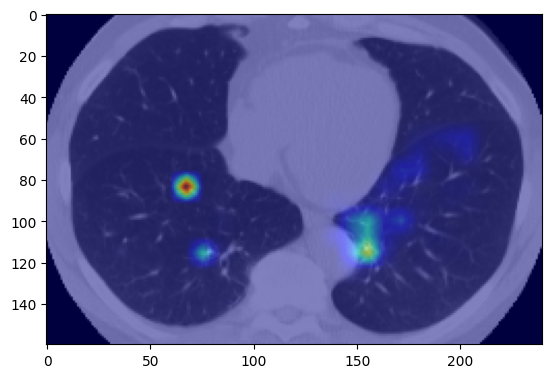

In [80]:
index = 35
plt.imshow(image[0, index, :, :], cmap='gray')
# plt.imshow(cls_attn[0, index, :, :], cmap='jet', alpha=0.5)
plt.imshow(attn[0, index, :, :], cmap='jet', alpha=0.5)

In [10]:
cls_attn.sum()

tensor(nan)